Data Combination

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
Plotting libraries
'''
import pandas as pd
import matplotlib.cm as cm
#from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
from sklearn import datasets, decomposition
from sklearn.manifold import TSNE

from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report

In [ ]:
!pip install venn

  Preparing metadata (setup.py) ... done
  Created wheel for venn: filename=venn-0.1.3-py3-none-any.whl size=19699 sha256=e2da2fe0a0e76a6180b425fed177bc7b1f57da9acdf8f685d06a6b5c672e4d26
  Stored in directory: /root/.cache/pip/wheels/9c/ce/43/705b4a04cd822891d1d7a4c43fc444b4798978e72c79528c5f
Successfully built venn


https://github.com/ecrl/padelpy

https://onlinelibrary.wiley.com/doi/10.1002/jcc.21707

https://dataprofessor.github.io/ws/bioinformatics/cheminformatics/padelpy/scikit-learn/qsar/qspr/2021/07/06/padelpy.html#Prepare-data-subset-as-input-to-PaDEL

#  Find out unique molecular

## 1. reorder CID for combine and generate dataset include molecular name

In [ ]:
# arc dataset reorder dataindex
arc = pd.read_csv('/content/drive/MyDrive/pgml/binary data/arc_behavior_1.csv')#.set_index('CAS')
df_arc=pd.read_csv('/content/drive/MyDrive/pgml/binary data/arc_molecules.csv')#.set_index('CAS')
# Remove rows where 'column_name' has NaN values
df_arc_reordered = df_arc.set_index('CID').reindex(arc['CID']).reset_index()
df_arc_reordered.to_csv('arc_m.csv')
df_arc_reordered

,CID,MolecularWeight,IsomericSMILES,IUPACName,name
0,10569,302.50,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,"(1R,4aR,4bR,10aR)-1,4a-dimethyl-7-propan-2-yl-...",abietic acid
1,101602,290.50,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,"(1,4a-dimethyl-7-propan-2-yl-2,3,4,4b,5,6,7,9,...",dihydroabietyl alcohol
2,177,44.05,CC=O,acetaldehyde,acetaldehyde
3,22235151,210.27,CC(OCCOC)OCC1=CC=CC=C1,1-(2-methoxyethoxy)ethoxymethylbenzene,benzyl methoxyethyl acetal
4,83036,202.33,CC(C)CCOC(C)OCCC(C)C,3-methyl-1-[1-(3-methylbutoxy)ethoxy]butane,13002-09-0
...,...,...,...,...,...
3097,10687,122.16,CC1=C(C(=CC=C1)O)C,"2,3-dimethylphenol","2,3-dimethylphenol"
3098,61814,134.17,CC1=CC(=C(C=C1)C=O)C,"2,4-dimethylbenzaldehyde","2,4-dimethylbenzaldehyde"
3099,33942,150.22,CC1=C(C(=CC=C1)C)CCO,"2-(2,6-dimethylphenyl)ethanol","2-(2,6-dimethylphenyl)ethanol"
3100,31211,194.23,CC(=O)CCC1=CC(=C(C=C1)O)OC,4-(4-hydroxy-3-methoxyphenyl)butan-2-one,zingerone


In [ ]:
sigma = pd.read_csv('/content/drive/MyDrive/pgml/binary data/sigma_behavior.csv')#.set_index('CAS')
df_sig=pd.read_csv('/content/drive/MyDrive/pgml/binary data/molecules_sigma.csv')#.set_index('CAS')
# Remove rows where 'column_name' has NaN values
df_sig_reordered = df_sig.set_index('CID').reindex(sigma['CID']).reset_index()
df_sig_reordered.to_csv('sig_m.csv')
df_sig_reordered

,CID,MolecularWeight,IsomericSMILES,IUPACName,name
0,-69,NaN,NaN,NaN,NaN
1,-68,NaN,NaN,NaN,NaN
2,-67,NaN,NaN,NaN,NaN
3,-66,NaN,NaN,NaN,NaN
4,-65,NaN,NaN,NaN,NaN
...,...,...,...,...,...
936,44134940,422.50,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,"calcium;1,1-dioxo-1,2-benzothiazol-2-id-3-one;...",calcium saccharin
937,54675810,176.12,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,"(2R)-2-[(1R)-1,2-dihydroxyethyl]-3,4-dihydroxy...",erythorbic acid
938,55251157,154.24,CC1=CN=C(C(=N1)C)SC,"3,5-dimethyl-2-methylsulfanylpyrazine",67952-65-2
939,91001317,64.08,CC.OO,ethane;hydrogen peroxide,"pyroligneous acids, reaction products with et ..."


In [ ]:
# leffingwell dataset
Lef = pd.read_csv('/content/drive/MyDrive/pgml/binary data/lef_behavior_a.csv')#.set_index('CAS')
Lef.rename(columns={'Stimulus': 'CID'}, inplace=True)
# Remove rows where 'column_name' has NaN values
Lef.dropna(subset=['IsomericSMILES'], inplace=True)
Lef.to_csv('lef_clean.csv',index=False)
Lef

,name,IsomericSMILES,CID,alcoholic,aldehydic,alliaceous,almond,animal,anisic,apple,...,tobacco,tomato,tropical,vanilla,vegetable,violet,warm,waxy,winey,woody
0,Hexenyl nonanoate,CCCCC=COC(=O)CCCCCCCC,-9.550000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,Tetrahydrocuminyl acetate,CC(=O)OCC1C=CC(C(C)C)CC1,-9.230000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Methyl acetoxydecanoate,CCCCCCCCC(OC(C)=O)C(=O)OC,-8.740000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Hexenyl methylvalerate,CCCCC=COC(=O)C(C)CCC,-8.740000e+11,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,Ethoxymethylbutanethiol,CCCC(S)COCC,-8.630000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3517,"4,4,5-triethyltrithiane",CCC1CSSSC1(CC)CC,1.542414e+08,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3518,schembl22694105,CC(S)SS,1.553234e+08,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3519,O-(2-methylpropyl) 2-methylbutanethioate,CCC(C)C(=S)OCC(C)C,1.586998e+08,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3520,non-1-enyl butanoate,CCCCCCCC=COC(=O)CCC,1.615049e+08,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


## Clean dataset: remove nan in IsomericSMILES

In [ ]:
# arc dataset
arc = pd.read_csv('/content/drive/MyDrive/pgml/binary data/arc_behavior_1.csv')#.set_index('CAS')
# Remove rows where 'column_name' has NaN values
arc.dropna(subset=['IsomericSMILES'], inplace=True)
arc.to_csv('arc_clean.csv',index=False)
arc

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,tobacco,vanilla,vanillin,vanlilin,violet,waxy,winey,woney,wood,woody
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,acetaldehyde,CC=O,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,13002-09-0,CC(C)CCOC(C)OCCC(C)C,83036,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3097,"2,3-dimethylphenol",CC1=C(C(=CC=C1)O)C,10687,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3098,"2,4-dimethylbenzaldehyde",CC1=CC(=C(C=C1)C=O)C,61814,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3099,"2-(2,6-dimethylphenyl)ethanol",CC1=C(C(=CC=C1)C)CCO,33942,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3100,zingerone,CC(=O)CCC1=CC(=C(C=C1)O)OC,31211,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
sigma = pd.read_csv('/content/drive/MyDrive/pgml/binary data/sigma_behavior.csv')#.set_index('CAS')
sigma.dropna(subset=['IsomericSMILES'], inplace=True)
sigma.iloc[:, 3:] = sigma.iloc[:, 3:].apply(lambda x: x.astype(int))
sigma.to_csv('sigma_clean.csv',index=False)
sigma

,name,IsomericSMILES,CID,potato,marigold,anise,herba-,caraway,tropical,rose,...,alliaceous,meaty,coconut,cinnamon,cabbage,mango,lavender,beer,ethereal,balsamic
69,2-oxobutanoic acid,CCC(=O)C(=O)O,58,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
71,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,acetic acid,CC(=O)O,176,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
937,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## save all molecular name and smiles
arc_m=arc.iloc[:,:3]
Lef_m=Lef.iloc[:,:3]
sigma_m=sigma.iloc[:,:3]
sigma_m
all_data=pd.concat([arc_m,Lef_m,sigma_m],axis=0)


In [ ]:
## save
all_data.to_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/all_data.csv',index=False)

In [ ]:
all_data_a=pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/common/update17jan/all_data.csv')
all_data_a

,name,IsomericSMILES,CID
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0
2,acetaldehyde,CC=O,177.0
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0
4,13002-09-0,CC(C)CCOC(C)OCCC(C)C,83036.0
...,...,...,...
7213,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0
7214,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810.0
7215,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0
7216,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0


## Find out commom molecules and remove



1

In [ ]:
# Find common elements between the two columns
common_la = pd.merge(Lef,arc, left_on='CID', right_on='CID', how='inner')
# Rename the columns in the new DataFrame (optional)
common_la.rename(columns={'CID': 'CommonCID'}, inplace=True)
common_la.rename(columns={'IsomericSMILES_x': 'IsomericSMILES'}, inplace=True)
# Display the common elements in a new DataFrame
common_la.drop_duplicates(subset='CommonCID')
common_la.to_csv('common_la.csv',index=False)
common_la

,name_x,IsomericSMILES,CommonCID,alcoholic,aldehydic_x,alliaceous,almond_x,animal_x,anisic_x,apple_x,...,tobacco_y,vanilla_y,vanillin,vanlilin,violet_y,waxy_y,winey_y,woney,wood,woody_y
0,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,acetaldehyde,CC=O,177.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,isoamyl undecanoate,CCCCCCCCCCC(=O)OCCC(C)C,53959463.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1182,isoamyl 4-(2-furan)butyrate,CC(C)CCOC(=O)CCCC1=CC=CO1,68968644.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1183,octadienol,CCCCC=CC=CO,71366249.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1184,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


2

In [ ]:
# Find common elements between the two columns
com_CID_ls = pd.merge(Lef,sigma, left_on='CID', right_on='CID', how='inner')
# Rename the columns in the new DataFrame (optional)
com_CID_ls.rename(columns={'CID': 'CommonCID'}, inplace=True)
com_CID_ls.rename(columns={'IsomericSMILES_x': 'IsomericSMILES'}, inplace=True)
# Display the common elements in a new DataFrame
com_CID_ls.drop_duplicates(subset='CommonCID')
com_CID_ls.to_csv('common_ls.csv',index=False)
com_CID_ls

,name_x,IsomericSMILES,CommonCID,alcoholic,aldehydic,alliaceous_x,almond_x,animal_x,anisic,apple_x,...,alliaceous_y,meaty_y,coconut_y,cinnamon_y,cabbage_y,mango,lavender,beer,ethereal_y,balsamic_y
0,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,isoamyl tiglate,C/C=C(\C)/C(=O)OCCC(C)C,5463682.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
732,ethyl trans-2-decenoate,CCCCCCC/C=C/C(=O)OCC,5463904.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
733,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
734,cis-3-hexenyl cis-3-hexenoate,CC/C=C\CCOC(=O)C/C=C\CC,6435882.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


3

In [ ]:
com_CID_as = pd.merge(arc,sigma, left_on='CID', right_on='CID', how='inner')
# Rename the columns in the new DataFrame (optional)
com_CID_as.rename(columns={'CID': 'CommonCID'}, inplace=True)
com_CID_as.rename(columns={'IsomericSMILES_x': 'IsomericSMILES'}, inplace=True)
# Display the common elements in a new DataFrame
# Display the common elements in a new DataFrame
com_CID_as.drop_duplicates(subset='CommonCID')
com_CID_as.to_csv('common_as.csv',index=False)
com_CID_as

,name_x,IsomericSMILES,CommonCID,acid,aldehidic,aldehydic,almond_x,almondy,ambre,animal_x,...,alliaceous,meaty,coconut_y,cinnamon,cabbage,mango,lavender,beer,ethereal_y,balsamic_y
0,acetaldehyde,CC=O,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,acetal,CCOC(C)OCC,7765,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"4-methyl-2-phenyl-1,3-dioxolane",CC1COC(O1)C2=CC=CC=C2,595928,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"4-methyl-2-phenyl-1,3-dioxolane",CC1COC(O1)C2=CC=CC=C2,595928,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,(2-(1-propoxyethoxy)ethyl)benzene,CCCOC(C)OCCC1=CC=CC=C1,61403,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,vanillin,COC1=C(C=CC(=C1)C=O)O,1183,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,vanillyl alcohol,COC1=C(C=CC(=C1)CO)O,62348,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,"1,2-dimethoxybenzene",COC1=CC=CC=C1OC,7043,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
499,vetiveryl acetate,CC1CC(C=C(C2C1CC(=C(C)C)C2)C)OC(=O)C,8347,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Find common elements between the two columns
common_CID_2 = pd.merge(common_la,sigma, left_on='CommonCID', right_on='CID', how='inner')

# Rename the columns in the new DataFrame (optional)
common_CID_2.rename(columns={'CommonCID': 'CommonCID2'}, inplace=True)
# Display the common elements in a new DataFrame
#print(common_CID)
common_CID_2.to_csv('common_CID_3.csv',index=False)

common_CID_2

,name_x,IsomericSMILES_x,CommonCID2,alcoholic,aldehydic_x,alliaceous_x,almond_x,animal_x,anisic_x,apple_x,...,alliaceous_y,meaty_y,coconut,cinnamon_y,cabbage_y,mango,lavender,beer,ethereal,balsamic
0,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,acetaldehyde,CC=O,177.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,geranyl phenylacetate,CC(=CCC/C(=C/COC(=O)CC1=CC=CC=C1)/C)C,5366044.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
460,cis-3-hexenyl phenylacetate,CC/C=C\CCOC(=O)CC1=CC=CC=C1,5367698.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
461,cis-3-hexenyl benzoate,CC/C=C\CCOC(=O)C1=CC=CC=C1,5367706.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
462,geranyl tiglate,C/C=C(\C)/C(=O)OC/C=C(\C)/CCC=C(C)C,5367785.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Drop out common mol

In [ ]:
# Drop rows where 'col1' in df matches 'col1' in value_to_drop
Lef2 = Lef[~Lef['CID'].isin(common_la['CommonCID'])]
Lef3 = Lef2[~Lef2['CID'].isin(com_CID_ls['CommonCID'])]
Lef3.to_csv('lef.csv',index=False)
Lef3

,name,IsomericSMILES,CID,alcoholic,aldehydic,alliaceous,almond,animal,anisic,apple,...,tobacco,tomato,tropical,vanilla,vegetable,violet,warm,waxy,winey,woody
0,Hexenyl nonanoate,CCCCC=COC(=O)CCCCCCCC,-9.550000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,Tetrahydrocuminyl acetate,CC(=O)OCC1C=CC(C(C)C)CC1,-9.230000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Methyl acetoxydecanoate,CCCCCCCCC(OC(C)=O)C(=O)OC,-8.740000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Hexenyl methylvalerate,CCCCC=COC(=O)C(C)CCC,-8.740000e+11,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,Ethoxymethylbutanethiol,CCCC(S)COCC,-8.630000e+11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3517,"4,4,5-triethyltrithiane",CCC1CSSSC1(CC)CC,1.542414e+08,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3518,schembl22694105,CC(S)SS,1.553234e+08,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3519,O-(2-methylpropyl) 2-methylbutanethioate,CCC(C)C(=S)OCC(C)C,1.586998e+08,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3520,non-1-enyl butanoate,CCCCCCCC=COC(=O)CCC,1.615049e+08,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [ ]:
# Drop rows where 'col1' in df matches 'col1' in value_to_drop
arc2 = arc[~arc['CID'].isin(common_la['CommonCID'])]
arc3 = arc2[~arc2['CID'].isin(com_CID_as['CommonCID'])]
arc3.to_csv('arc.csv',index=False)
arc3

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,tobacco,vanilla,vanillin,vanlilin,violet,waxy,winey,woney,wood,woody
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094,divinyl sulfide,C=CSC=C,12321,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3095,o-xylene,CC1=CC=CC=C1C,7237,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3096,"1,6-dimethyl-7-oxabicyclo[4.1.0]hepta-2,4-diene",CC12C=CC=CC1(O2)C,12966232,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3099,"2-(2,6-dimethylphenyl)ethanol",CC1=C(C(=CC=C1)C)CCO,33942,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Drop rows where 'col1' in df matches 'col1' in value_to_drop
sig2 = sigma[~sigma['CID'].isin(com_CID_ls['CommonCID'])]
sig3 = sig2[~sig2['CID'].isin(com_CID_as['CommonCID'])]
sig3.to_csv('sig.csv',index=False)
sig3

,name,IsomericSMILES,CID,potato,marigold,anise,herba-,caraway,tropical,rose,...,alliaceous,meaty,coconut,cinnamon,cabbage,mango,lavender,beer,ethereal,balsamic
83,hydrochloric acid,Cl,313,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
88,salicylic acid,C1=CC=C(C(=C1)C(=O)O)O,338,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,dimethyl sulfoxide,CS(=O)C,679,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
122,69097-99-0,COC1=C(C=C(C=C1)C2CC(=O)C3=C(C=C(C=C3O2)O)O)O,3593,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
133,l-lysine,C(CCN)C[C@@H](C(=O)O)N,5962,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Combine (arc,lef and sig)


##  Combine together

In [ ]:
com=pd.concat([arc3,Lef3,sig3])
# Identify and remove duplicated columns
com2 = com.loc[:, ~com.columns.duplicated()]
com2

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0,NaN,NaN,NaN,1,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Replace NaN values with 0
com2.fillna(0, inplace=True)
com2.to_csv('combine.csv',index=False)
com2

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0,0.0,0.0,0.0,1,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
com = pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/clean_1810/combine.csv')#.set_index('CAS')
com

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3785,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3786,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3787,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0,0.0,0.0,0.0,1,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3788,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# combine dataset reorder dataindex
#com = pd.read_csv('/content/drive/MyDrive/pgml/Data analysis/clean_1810/combine.csv')#.set_index('CAS')
#com
#com = com.drop_duplicates(subset=['CID'], keep='first')
#com
com = com.drop_duplicates(subset=['CID'], keep='first')
com

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0,NaN,NaN,NaN,1,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Some molecular cannot generated by padelpy features

In [ ]:
com2 = com.drop(com[com['name'] == 'tannic acid'].index)
com3 = com2.drop(com2[com2['name'] == 'saponin'].index)
com4 = com3.drop(com3[com3['IsomericSMILES'] == 'S'].index)
com4_f=com4.loc[:, (com4!= 0).any(axis=0)]
com4_f


,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
0,abietic acid,CC(C)C1=CC2=CC[C@@H]3[C@@]([C@H]2CC1)(CCC[C@@]...,10569.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dihydroabietyl alcohol,CC(C)C1CCC2C(=C1)CCC3C2(CCCC3(C)CO)C,101602.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,benzyl methoxyethyl acetal,CC(OCCOC)OCC1=CC=CC=C1,22235151.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"2-methyl-1,3-dioxocane",CC1OCCCCCO1,68074566.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,"2,2-diethoxypropane",CCOC(C)(C)OCC,31361.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,galactoarabinan,CC1C(C(C(C(O1)CO)O)OC2C(C(C(C(O2)COC3C(C(C(CO3...,24847856.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
936,calcium saccharin,C1=CC=C2C(=C1)C(=O)[N-]S2(=O)=O.C1=CC=C2C(=C1)...,44134940.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
938,67952-65-2,CC1=CN=C(C(=N1)C)SC,55251157.0,NaN,NaN,NaN,1,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
939,"pyroligneous acids, reaction products with et ...",CC.OO,91001317.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
com4.to_csv('/content/drive/MyDrive/pgml/Data analysis/clean_1810/combine_2011.csv')

<Axes: >

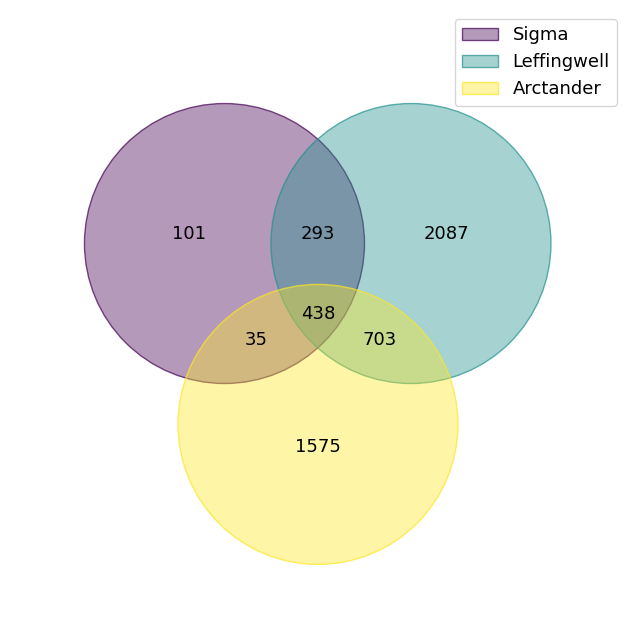

In [ ]:
from venn import venn
%matplotlib inline
comid={}
comid['Sigma']=set(sigma['CID'])
comid['Leffingwell']=set(Lef['CID'])
comid['Arctander']=set(arc['CID'])
venn(comid)

# Find out Common mol

In [ ]:
# find out Lef with commond CID
filtered_lef = Lef[Lef['CID'].isin(common_la['CommonCID'])]
#filtered_lef.drop(filtered_lef.columns[[0]], axis=1, inplace=True)
filtered_lef2 = Lef[Lef['CID'].isin(com_CID_ls['CommonCID'])]
#filtered_lef.drop(filtered_lef.columns[[0]], axis=1, inplace=True)
filtered_lef2
filtered_arc = arc[arc['CID'].isin(common_la['CommonCID'])]
#filtered_arc.drop(filtered_arc.columns[[0]], axis=1, inplace=True)
filtered_arc2 = arc[arc['CID'].isin(com_CID_as['CommonCID'])]
#filtered_arc.drop(filtered_arc.columns[[0]], axis=1, inplace=True)
filtered_arc2
filtered_sigma = sigma[sigma['CID'].isin(com_CID_ls['CommonCID'])]
#filtered_sigma.drop(filtered_sigma.columns[[0]], axis=1, inplace=True)
filtered_sigma2 = sigma[sigma['CID'].isin(com_CID_as['CommonCID'])]
#filtered_sigma.drop(filtered_sigma.columns[[0]], axis=1, inplace=True)
filtered_sigma2

,name,IsomericSMILES,CID,potato,marigold,anise,herba-,caraway,tropical,rose,...,alliaceous,meaty,coconut,cinnamon,cabbage,mango,lavender,beer,ethereal,balsamic
70,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
71,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,acetic acid,CC(=O)O,176,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
74,acetaldehyde,CC=O,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
75,benzaldehyde,C1=CC=C(C=C1)C=O,240,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,cis-3-hexenyl salicylate,CC/C=C\CCOC(=O)C1=CC=CC=C1O,5371102,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
909,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
926,cis-3-hexenyl tiglate,CC/C=C\CCOC(=O)/C(=C/C)/C,15461361,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
930,cis-3-hexenyl crotonate,CC/C=C\CCOC(=O)/C=C/C,16220110,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
sig_c=pd.concat([filtered_sigma,filtered_sigma2])
lef_c=pd.concat([filtered_lef,filtered_lef2])
arc_c=pd.concat([filtered_arc,filtered_arc2])

## Binary data convert back to list data and name as smell

In [ ]:

arc
arc1=arc.iloc[:,3:]
arc1['Smell'] = (arc1.stack()
   .loc[lambda x: x>0]
   .reset_index()
   .groupby('level_0')
   .agg({'level_1':list})
)

#arc1=arc1.dropna()
arc_result = arc[arc.index.isin(arc1.index)]  # match the index
# Display the result
#arc_result
arc2=pd.concat([arc_result,arc1.iloc[:,-1]],axis=1)
arc2.to_csv('arc_label.csv')

In [ ]:
arc_c.loc[:, (arc_c != 0).any(axis=0)]

arc_c1=arc_c.iloc[:,3:]

arc_c1['Smell'] = (arc_c1.stack()
   .loc[lambda x: x>0]
   .reset_index()
   .groupby('level_0')
   .agg({'level_1':list})
)

#arc_c1=arc_c1.dropna()
arc_result = arc_c[arc_c.index.isin(arc_c1.index)]  # match the index
# Display the result
#arc_result
arc_c2=pd.concat([arc_result,arc_c1.iloc[:,-1]],axis=1)
arc_c2

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,vanilla,vanillin,vanlilin,violet,waxy,winey,woney,wood,woody,Smell
2,acetaldehyde,CC=O,177,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,"[ethereal, winey, ethereal, winey]"
4,13002-09-0,CC(C)CCOC(C)OCCC(C)C,83036,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[green, oily]"
5,acetal,CCOC(C)OCC,7765,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[fruity, green, fruity, green]"
6,63449-64-9,CC/C=C\CCOC(OCC/C=C\CC)C,5367767,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[green, oily]"
8,"1,1-dipropoxyethane",CCCOC(C)OCCC,66929,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,"[ethereal, winey]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3077,"1,2-dimethoxybenzene",COC1=CC=CC=C1OC,7043,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,"[creamy, vanillin, creamy, vanillin]"
3081,vetiveryl acetate,CC1CC(C=C(C2C1CC(=C(C)C)C2)C)OC(=O)C,8347,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"[woody, woody]"
3093,2-methoxy-4-vinylphenol,COC1=C(C=CC(=C1)C=C)O,332,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"[balsamic, spicy, woody, balsamic, spicy, woody]"
3098,"2,4-dimethylbenzaldehyde",CC1=CC(=C(C=C1)C=O)C,61814,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,"[almond, floral, almond, floral]"


In [ ]:
lef_c.loc[:, (lef_c != 0).any(axis=0)]

lef_c1=lef_c.iloc[:,3:]
lef_c1['Smell'] = (lef_c1.stack()
   .loc[lambda x: x>0]
   .reset_index()
   .groupby('level_0')
   .agg({'level_1':list})
)

#lef_c1=lef_c1.dropna()
lef_result = lef_c[lef_c.index.isin(lef_c1.index)]  # match the index
# Display the result
#lef_result
lef_c2=pd.concat([lef_result,lef_c1.iloc[:,-1]],axis=1)
lef_c2

,name,IsomericSMILES,CID,alcoholic,aldehydic,alliaceous,almond,animal,anisic,apple,...,tomato,tropical,vanilla,vegetable,violet,warm,waxy,winey,woody,Smell
39,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[balsamic, sweet, balsamic, sweet]"
41,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,"[almond, balsamic, hay, nutty, phenolic, woody..."
44,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[pungent, sour, pungent, sour]"
45,acetaldehyde,CC=O,177.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[alcoholic, nutty, pungent, alcoholic, nutty, ..."
46,acetoin,CC(C(=O)C)O,179.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[buttery, creamy]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,isoamyl tiglate,C/C=C(\C)/C(=O)OCCC(C)C,5463682.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,"[apple, chamomile, fruity, herbal, winey]"
2970,ethyl trans-2-decenoate,CCCCCCC/C=C/C(=O)OCC,5463904.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,"[apple, citrus, fruity, green, pear, waxy]"
3002,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390.0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,"[honey, sweet, vanilla, honey, sweet, vanilla]"
3079,cis-3-hexenyl cis-3-hexenoate,CC/C=C\CCOC(=O)C/C=C\CC,6435882.0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,"[apple, fruity, green, leafy, melon, pear, tom..."


In [ ]:
sig_c.loc[:, (sig_c != 0).any(axis=0)]

sig_c1=sig_c.iloc[:,3:]
sig_c1['Smell'] = (sig_c1.stack()
   .loc[lambda x: x>0]
   .reset_index()
   .groupby('level_0')
   .agg({'level_1':list})
)
#sig_c1=sig_c1.dropna()
sig_result = sig_c[sig_c.index.isin(sig_c1.index)]  # match the index
# Display the result
#sig_result
sig_c2=pd.concat([sig_result,sig_c1.iloc[:,-1]],axis=1)
sig_c2

<ipython-input-31-ec8c86541eed>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sig_c1['Smell'] = (sig_c1.stack()


,name,IsomericSMILES,CID,potato,marigold,anise,herba-,caraway,tropical,rose,...,meaty,coconut,cinnamon,cabbage,mango,lavender,beer,ethereal,balsamic,Smell
69,2-oxobutanoic acid,CCC(=O)C(=O)O,58,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[creamy, caramel]"
70,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,"[rose, sweet, rose, sweet]"
71,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[sweet, lily, sweet, lily]"
72,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[caramel]
73,acetic acid,CC(=O)O,176,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,"[apple, ethereal, apple, ethereal]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,cis-3-hexenyl salicylate,CC/C=C\CCOC(=O)C1=CC=CC=C1O,5371102,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[green, balsam]"
909,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,"[apple, spicy, sweet, honey, cinnamon, apple, ..."
926,cis-3-hexenyl tiglate,CC/C=C\CCOC(=O)/C(=C/C)/C,15461361,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[banana, vegetable, fatty, pepper]"
930,cis-3-hexenyl crotonate,CC/C=C\CCOC(=O)/C=C/C,16220110,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[vegetable, green]"


In [ ]:
arc_c3=arc_c2[['name', 'IsomericSMILES','CID', arc_c2.columns[-1]]]
lef_c3=lef_c2[['name', 'IsomericSMILES','CID', lef_c2.columns[-1]]]
sig_c3=sig_c2[['name', 'IsomericSMILES','CID', sig_c2.columns[-1]]]
c_all_d2a=pd.concat([arc_c3,lef_c3,sig_c3])
c_all_d2a

,name,IsomericSMILES,CID,Smell
2,acetaldehyde,CC=O,177.0,"[ethereal, winey, ethereal, winey]"
4,13002-09-0,CC(C)CCOC(C)OCCC(C)C,83036.0,"[green, oily]"
5,acetal,CCOC(C)OCC,7765.0,"[fruity, green, fruity, green]"
6,63449-64-9,CC/C=C\CCOC(OCC/C=C\CC)C,5367767.0,"[green, oily]"
8,"1,1-dipropoxyethane",CCCOC(C)OCCC,66929.0,"[ethereal, winey]"
...,...,...,...,...
905,cis-3-hexenyl salicylate,CC/C=C\CCOC(=O)C1=CC=CC=C1O,5371102.0,"[green, balsam]"
909,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390.0,"[apple, spicy, sweet, honey, cinnamon, apple, ..."
926,cis-3-hexenyl tiglate,CC/C=C\CCOC(=O)/C(=C/C)/C,15461361.0,"[banana, vegetable, fatty, pepper]"
930,cis-3-hexenyl crotonate,CC/C=C\CCOC(=O)/C=C/C,16220110.0,"[vegetable, green]"


In [ ]:
c_all_d2=pd.concat([arc_c2,lef_c2,sig_c2])
c_all_d2

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,"alliaceous (onion, garlic)",blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer
2,acetaldehyde,CC=O,177.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13002-09-0,CC(C)CCOC(C)OCCC(C)C,83036.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,acetal,CCOC(C)OCC,7765.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,63449-64-9,CC/C=C\CCOC(OCC/C=C\CC)C,5367767.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"1,1-dipropoxyethane",CCCOC(C)OCCC,66929.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,cis-3-hexenyl salicylate,CC/C=C\CCOC(=O)C1=CC=CC=C1O,5371102.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
909,isoeugenyl phenylacetate,C/C=C/C1=CC(=C(C=C1)OC(=O)CC2=CC=CC=C2)OC,6114390.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
926,cis-3-hexenyl tiglate,CC/C=C\CCOC(=O)/C(=C/C)/C,15461361.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
930,cis-3-hexenyl crotonate,CC/C=C\CCOC(=O)/C=C/C,16220110.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
c_all_d2[['Smell']]

,Smell
2,"[ethereal, winey, ethereal, winey]"
4,"[green, oily]"
5,"[fruity, green, fruity, green]"
6,"[green, oily]"
8,"[ethereal, winey]"
...,...
905,"[green, balsam]"
909,"[apple, spicy, sweet, honey, cinnamon, apple, ..."
926,"[banana, vegetable, fatty, pepper]"
930,"[vegetable, green]"


In [ ]:
# prompt: reorder c_all_d2 by CID

c_all_d2_reorder=c_all_d2.sort_values('CID')
c_all_d2_reorder[['CID','Smell']]


,CID,Smell
69,58.0,"[creamy, caramel]"
36,58.0,"[caramellic, creamy, fatty, sweet]"
70,107.0,"[rose, sweet, rose, sweet]"
2578,107.0,"[balsamic, vanillin, balsamic, vanillin]"
2578,107.0,"[balsamic, vanillin, balsamic, vanillin]"
...,...,...
3405,71366249.0,"[green, leafy, mushroom]"
443,73555259.0,"[apricot, fatty, fruity, green, oily, peach]"
3423,73555259.0,"[fatty, woody]"
2592,102283665.0,"[banana, floral, fruity, green, oily]"


In [ ]:
# Group by the 'ID' column and concatenate the values in the 'Info' column
c_all_d2['Smell'] =  c_all_d2['Smell'].astype(str).str.replace(r'\[|\]', '')
result_c_all_d2 = c_all_d2.groupby('CID')['Smell'].agg(lambda x: ', '.join(x)).reset_index()

# Merge the result back to the original DataFrame based on the 'ID' column
c_all_d2_combined = pd.merge(c_all_d2, result_c_all_d2, on='CID')

# Rename the last column
c_all_d2_combined = c_all_d2_combined.rename(columns={'Info_y': 'Combined_Info'})


In [ ]:
c_all_d2_combined[['CID','Smell_y']]

,CID,Smell_y
0,177.0,"['ethereal', 'winey', 'ethereal', 'winey'], ['..."
1,177.0,"['ethereal', 'winey', 'ethereal', 'winey'], ['..."
2,177.0,"['ethereal', 'winey', 'ethereal', 'winey'], ['..."
3,177.0,"['ethereal', 'winey', 'ethereal', 'winey'], ['..."
4,177.0,"['ethereal', 'winey', 'ethereal', 'winey'], ['..."
...,...,...
4763,5463904.0,"['apple', 'citrus', 'fruity', 'green', 'pear',..."
4764,6435882.0,"['apple', 'fruity', 'green', 'leafy', 'melon',..."
4765,6435882.0,"['apple', 'fruity', 'green', 'leafy', 'melon',..."
4766,54675810.0,"['odorless'], ['vanilla', 'woody']"


In [ ]:
# prompt: reorder c_all_d2_combined 'CID column from small to large

c_all_d2_combined = c_all_d2_combined.sort_values('CID')
c_all_d2_combined[['CID','Smell_y']]


,CID,Smell_y
4181,58.0,"['caramellic', 'creamy', 'fatty', 'sweet'], ['..."
4182,58.0,"['caramellic', 'creamy', 'fatty', 'sweet'], ['..."
3474,107.0,"['balsamic', 'vanillin', 'balsamic', 'vanillin..."
3472,107.0,"['balsamic', 'vanillin', 'balsamic', 'vanillin..."
3473,107.0,"['balsamic', 'vanillin', 'balsamic', 'vanillin..."
...,...,...
3181,71366249.0,"['buttery', 'creamy', 'green', 'oily'], ['gree..."
743,73555259.0,"['apricot', 'fatty', 'fruity', 'green', 'oily'..."
744,73555259.0,"['apricot', 'fatty', 'fruity', 'green', 'oily'..."
3504,102283665.0,"['banana', 'floral', 'fruity', 'green', 'oily'..."


In [ ]:
## clean the label format
c_all3=c_all_d2_combined.drop_duplicates()
c_all4=c_all3.drop(columns=['Smell_x'])
c_all4['Smell_y']=c_all4['Smell_y'].str.replace("'","")
def remove_last_comma(s):
    return s.rstrip(', ')
def remove_start_comma(s):
    return s.strip(', ')
# Apply the function to each element in the DataFrame
c_all4['Smell_y'] = c_all4['Smell_y'].apply(remove_last_comma)
c_all4['Smell_y'] = c_all4['Smell_y'].apply(remove_start_comma)
c_all4

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer,Smell_y
4181,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[caramellic, creamy, fatty, sweet], [creamy, c..."
4182,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[caramellic, creamy, fatty, sweet], [creamy, c..."
3474,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[balsamic, vanillin, balsamic, vanillin], [bal..."
3472,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[balsamic, vanillin, balsamic, vanillin], [bal..."
3476,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[balsamic, vanillin, balsamic, vanillin], [bal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3181,octadienol,CCCCC=CC=CO,71366249.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[buttery, creamy, green, oily], [green, leafy,..."
743,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[apricot, fatty, fruity, green, oily, peach], ..."
744,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[apricot, fatty, fruity, green, oily, peach], ..."
3504,decanoic acid 3-phenylpropyl ester,CCCCCCCCCC(=O)OCCCC1=CC=CC=C1,102283665.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[banana, floral, fruity, green, oily], [banana..."


In [ ]:
c_all5=c_all4.drop_duplicates(subset='CID')
c_all5

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer,Smell_y
4181,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[caramellic, creamy, fatty, sweet], [creamy, c..."
3474,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[balsamic, vanillin, balsamic, vanillin], [bal..."
2372,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[balsamic, woody, balsamic, woody], [balsamic,..."
4183,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[odorless], [caramel]"
52,acetic acid,CC(=O)O,176.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[sour, sour], nan, [sour, sour], nan, [pungent..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4766,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[odorless], [vanilla, woody]"
343,isoamyl 4-(2-furan)butyrate,CC(C)CCOC(=O)CCCC1=CC=CO1,68968644.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[buttery, caramelic, fruity], [buttery, fruity..."
3182,octadienol,CCCCC=CC=CO,71366249.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[buttery, creamy, green, oily], [green, leafy,..."
743,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[apricot, fatty, fruity, green, oily, peach], ..."


Convert to binary data

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
#c_all4['Smell_y']=c_all4['Smell_y'].str.replace("'","")
# Convert multi-labels to binary representation
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(c_all5['Smell_y'].str.split(', '))# https://stackoverflow.com/questions/57917936/multilabelbinarizer-gives-individual-characters-instead-of-the-classes
# Create a new DataFrame with the binary matrix
column_names = mlb.classes_
binary_df = pd.DataFrame(binary_matrix, columns=column_names)
# Map the original labels to custom column names
#column_mapping = {label: f'Label_{label}' for label in mlb.classes_}

# Create a new DataFrame with the binary matrix and custom column names
#binary_df = pd.DataFrame(binary_matrix, columns=[column_mapping[label] for label in mlb.classes_])

# Concatenate the new DataFrame with the original DataFrame
result_df = pd.concat([c_all5, binary_df], axis=1)

result_df

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,waxy],whiskey,wine-like,wine-like],winelike,winey,winey],wood],woody,woody]
4181,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3474,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2372,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4183,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,acetic acid,CC(=O)O,176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
c_all5_f=c_all5.loc[:, (c_all5!= 0).any(axis=0)]
c_all5_f

,name,IsomericSMILES,CID,acid,aldehidic,aldehydic,almond,almondy,ambre,animal,...,blossom,raspberry,fennel,iris,corn,balsam,mango,lavender,beer,Smell_y
4181,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[caramellic, creamy, fatty, sweet], [creamy, c..."
3474,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[balsamic, vanillin, balsamic, vanillin], [bal..."
2372,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,NaN,NaN,NaN,0,NaN,NaN,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[balsamic, woody, balsamic, woody], [balsamic,..."
4183,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[odorless], [caramel]"
52,acetic acid,CC(=O)O,176.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[sour, sour], nan, [sour, sour], nan, [pungent..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4766,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[odorless], [vanilla, woody]"
343,isoamyl 4-(2-furan)butyrate,CC(C)CCOC(=O)CCCC1=CC=CO1,68968644.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[buttery, caramelic, fruity], [buttery, fruity..."
3182,octadienol,CCCCC=CC=CO,71366249.0,NaN,NaN,0.0,0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[buttery, creamy, green, oily], [green, leafy,..."
743,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,0.0,0.0,0.0,0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[apricot, fatty, fruity, green, oily, peach], ..."


In [ ]:
c_all6=c_all5.iloc[:,0:3]
c_all6

,name,IsomericSMILES,CID
4181,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0
3474,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0
2372,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0
4183,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0
52,acetic acid,CC(=O)O,176.0
...,...,...,...
4766,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810.0
343,isoamyl 4-(2-furan)butyrate,CC(C)CCOC(=O)CCCC1=CC=CO1,68968644.0
3182,octadienol,CCCCC=CC=CO,71366249.0
743,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0


In [ ]:
binary_df_f=binary_df.loc[:, (binary_df!= 0).any(axis=0)]
binary_df_f
binary_df_f

,[acid,[acid],[alcoholic,[aldehidic,[aldehydic,[alliaceous,[alliaceous (onion,[almond,[almond],[almondy,...,waxy],whiskey,wine-like,wine-like],winelike,winey,winey],wood],woody,woody]
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1465,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1466,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1467,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
c_all6.reset_index(drop=True, inplace=True)
binary_df.reset_index(drop=True, inplace=True)
result_df = pd.concat([c_all6, binary_df],axis=1)
result_df

,name,IsomericSMILES,CID,[acid,[acid],[alcoholic,[aldehidic,[aldehydic,[alliaceous,[alliaceous (onion,...,waxy],whiskey,wine-like,wine-like],winelike,winey,winey],wood],woody,woody]
0,2-oxobutanoic acid,CCC(=O)C(=O)O,58.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,hydrocinnamic acid,C1=CC=C(C=C1)CCC(=O)O,107.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4-hydroxybenzaldehyde,C1=CC(=CC=C1C=O)O,126.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4-hydroxybenzoic acid,C1=CC(=CC=C1C(=O)O)O,135.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,acetic acid,CC(=O)O,176.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,erythorbic acid,C([C@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O,54675810.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1465,isoamyl 4-(2-furan)butyrate,CC(C)CCOC(=O)CCCC1=CC=CO1,68968644.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1466,octadienol,CCCCC=CC=CO,71366249.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1467,dtxsid10864074,CCCCCCCC=CC(=O)OCCCC,73555259.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
result_df.to_csv('/content/drive/MyDrive/pgml/Data analysis/common/all6.csv',index=False)

## Common Labels for plot

In [ ]:
Lef_label= Lef.columns
Lef_label= pd.Index(Lef_label,name='Label')
# Convert index to DataFrame
Lef_label = Lef_label.to_frame(index=False)
Lef_label=Lef_label.iloc[3:, :]
#df1 = df.iloc[1:]
#Lef_label.rename(columns={'index': 'Label'}, inplace=True)
Lef_label

,Label
3,alcoholic
4,aldehydic
5,alliaceous
6,almond
7,animal
...,...
111,violet
112,warm
113,waxy
114,winey


In [ ]:

arc_label= arc.columns

arc_label= pd.Index(arc_label,name='Label')

# Convert index to DataFrame
arc_label = arc_label.to_frame(index=False)
arc_label=arc_label.iloc[1:, :]
arc_label = arc_label.iloc[2:]
arc_label


,Label
3,acid
4,aldehidic
5,aldehydic
6,almond
7,almondy
...,...
102,waxy
103,winey
104,woney
105,wood


In [ ]:
sigma_label=sigma.columns
sigma_label= pd.Index(sigma_label,name='Label')

# Convert index to DataFrame
sigma_label = sigma_label.to_frame(index=False)
sigma_label=sigma_label.iloc[1:, :]
sigma_label = sigma_label.iloc[2:]
sigma_label

,Label
3,potato
4,marigold
5,anise
6,herba-
7,caraway
...,...
115,mango
116,lavender
117,beer
118,ethereal


<Axes: >

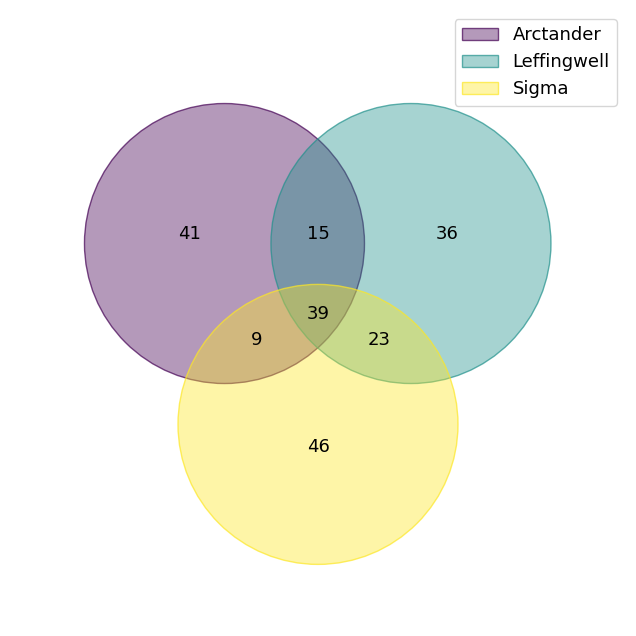

In [ ]:
from venn import venn
%matplotlib inline
comid={}
comid['Arctander']=set(arc_label['Label'])
comid['Leffingwell']=set(Lef_label['Label'])
comid['Sigma']=set(sigma_label['Label'])
venn(comid)

Common descriptors

In [ ]:
# Find common elements between the two columns
common_smell = pd.merge(Lef_label,arc_label, left_on='Label', right_on='Label', how='inner')

# Rename the columns in the new DataFrame (optional)
common_smell.rename(columns={'Label': 'CommonLabel'}, inplace=True)

# Display the common elements in a new DataFrame
print(common_smell)
common_smell.to_csv('common_smell.csv',index=False)

   CommonLabel
0    aldehydic
1       almond
2       animal
3       anisic
4        apple
5      apricot
6     aromatic
7     balsamic
8       banana
9        berry
10      brandy
11     buttery
12      citrus
13     coconut
14      creamy
15      earthy
16    ethereal
17       fatty
18      floral
19      fruity
20       grape
21       green
22         hay
23      herbal
24       honey
25       leafy
26    leathery
27   medicinal
28    metallic
29        mint
30    mushroom
31        musk
32       musty
33       nutty
34        oily
35      orange
36       orris
37       peach
38        pear
39    phenolic
40        pine
41   pineapple
42        plum
43        rose
44       smoky
45        sour
46       spicy
47         tea
48     tobacco
49     vanilla
50      violet
51        waxy
52       winey
53       woody


In [ ]:
# Find common elements between the two columns
common_smell2 = pd.merge(common_smell,sigma_label, left_on='CommonLabel', right_on='Label', how='inner')

# Rename the columns in the new DataFrame (optional)
common_smell2.rename(columns={'CommonLabel': 'CommonLabel2'}, inplace=True)

# Display the common elements in a new DataFrame
print(common_smell2)
common_smell2.to_csv('common_smell2.csv',index=False)

   CommonLabel2      Label
0        almond     almond
1        animal     animal
2         apple      apple
3       apricot    apricot
4      balsamic   balsamic
5        banana     banana
6         berry      berry
7        brandy     brandy
8        citrus     citrus
9       coconut    coconut
10       creamy     creamy
11       earthy     earthy
12     ethereal   ethereal
13        fatty      fatty
14       floral     floral
15       fruity     fruity
16        grape      grape
17        green      green
18        honey      honey
19        leafy      leafy
20    medicinal  medicinal
21     mushroom   mushroom
22        musty      musty
23        nutty      nutty
24         oily       oily
25       orange     orange
26        peach      peach
27         pear       pear
28    pineapple  pineapple
29         plum       plum
30         rose       rose
31        smoky      smoky
32         sour       sour
33        spicy      spicy
34      tobacco    tobacco
35      vanilla    vanilla
3